In [1]:
#Collins Machine Learning INternship Week 2
#Project: Data Processing and Feature Engineering for Machine Learning

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Data Inspection

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.isnull().sum().unique()

array([0])

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
#Data Cleaning 

In [12]:
#Total Charges is str instead of float

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], "coerce").astype(float)


In [14]:
#Checking for the values that need to be standardized

In [15]:
for column in df.select_dtypes(include = str).columns:
    print(f"\n {column}")
    print(df[column].unique())
    


 customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

 gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

 Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

 InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

 OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

 DeviceProtection
<StringArray>
['No', 'Yes', 'No internet 

In [16]:
List_to_standard= ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for i in List_to_standard: 
    df[i] = df[i].replace("No internet service","No")
    print(i)
    print(df[i].unique())
print("MultipleLines")
df["MultipleLines"]= df["MultipleLines"].replace("No phone service","No")
print(df["MultipleLines"].unique())

OnlineSecurity
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [17]:
#'No internet service' across internet options and 'No phone service' in MultipleLines were standardized to
##'No' to maintain uniform binary indicators across all service features.

In [18]:
#Feature Engineering(Preparing data for use)

In [19]:
df_Copy = df.copy()

In [20]:
df_Copy.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [21]:
#Creating Sum of Customers Services

In [22]:
Services = ["PhoneService","OnlineSecurity","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","OnlineBackup"]
df_Copy["Total Services"] = (df_Copy[Services] == 'Yes').sum(axis= 1)

In [23]:
df_Copy["Total Services"]

0       1
1       3
2       3
3       3
4       1
       ..
7038    6
7039    5
7040    1
7041    1
7042    6
Name: Total Services, Length: 7043, dtype: int64

In [24]:
#Users that partake in more services are less likely to churn than users that engage in small services that is why I found the total services


In [25]:
#Creating average historical monthly spend ratio

In [26]:
#adding +1 to the tenure to safely avoid division by zero when the tenure is zero

In [27]:
df_Copy["Avg_Monthly_Ratio"] = (df_Copy["TotalCharges"]/ (df_Copy["tenure"]+1))

In [28]:
df_Copy["Avg_Monthly_Ratio"] 

0        14.925000
1        53.985714
2        36.050000
3        40.016304
4        50.550000
           ...    
7038     79.620000
7039    100.861644
7040     28.870833
7041     61.320000
7042    102.156716
Name: Avg_Monthly_Ratio, Length: 7043, dtype: float64

In [29]:
# Comparing the previous payment amount with recent ones can give us insite into a customer that is likely to churn 
# Since price recent price jumps can cause some users to churn

In [30]:
#Automatic Payment Indicator 

In [31]:
df_Copy["Automatic_Payment"] = df_Copy['PaymentMethod'].apply(lambda x: 1 if "automatic" in str(x).lower() else 0)

In [32]:
df_Copy["Automatic_Payment"]

0       0
1       0
2       0
3       1
4       0
       ..
7038    0
7039    1
7040    0
7041    0
7042    1
Name: Automatic_Payment, Length: 7043, dtype: int64

In [33]:
# Users whose payment is automatically deducted is not likely to atchurn since the have built trust, interest and can afford the amount to be paid
# And also I don't think a user is going to churn after amount have been automatically deducted

In [34]:
#Family/ Multiple Accounts Indicator 

In [35]:
df_Copy['Has_Family'] = np.where((df_Copy["Partner"] == "Yes") | (df_Copy["Dependents"] == "Yes"),1,0)

In [36]:
df_Copy['Has_Family'].head(10)

0    1
1    0
2    0
3    0
4    0
5    0
6    1
7    0
8    1
9    1
Name: Has_Family, dtype: int64

In [37]:
#Users in groups or family are not likely to curn since they need to consult the other before than single individuals

In [38]:
#Clean Up and Removal Of Irrelevant Columns

In [39]:
if 'customerID' in df_Copy.columns:
    df_Copy.drop(columns=['customerID'], inplace=True)
    

In [40]:
#CustomerID are just random values given for identificaion and are not needed in building the ML model

In [41]:
df_Copy.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total Services,Avg_Monthly_Ratio,Automatic_Payment,Has_Family
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,14.925000,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,3,53.985714,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3,36.050000,0,0
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,40.016304,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,50.550000,0,0


In [42]:
#Feature Encoding and Scaling

In [43]:
#Working on the copy from part 3
df_Copy2= df_Copy.copy()

In [44]:
#Map Target Variable(Churn) using Target Binary Encoding
df_Copy2['Churn'] = df_Copy2['Churn'].map({'No':0,'Yes': 1})

In [45]:
df_Copy2['Churn'] 

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [46]:
#Ordinal Encoding For Contract lenght

In [47]:
Contract_order={'Month-to-month': 0,'One year': 1,'Two year': 2}
df_Copy2['Encoded_Contract'] = df_Copy2['Contract'].map(Contract_order)
df_Copy2.drop(columns=['Contract'], inplace=True)

In [48]:
df_Copy2['Encoded_Contract'].head()

0    0
1    1
2    0
3    1
4    0
Name: Encoded_Contract, dtype: int64

In [49]:
#One-Hot Encoding for mominal categorical columns

In [50]:
nominal_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 
    'PaymentMethod'
]

df_encoded = pd.get_dummies(df_Copy2, columns=nominal_cols, drop_first=True)

# Convert all boolean columns generated by get_dummies to integers (0 or 1)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded[bool_cols]

,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
1,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1
2,1,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1
3,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,1,0,0,1,0,1,1,1,1,1,0,0,1
7039,0,1,1,1,1,1,0,0,1,1,0,1,1,1,1,0,0
7040,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0
7041,1,1,0,1,1,1,0,0,0,0,0,0,0,1,0,0,1


In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
Num_Cols =['tenure', 'MonthlyCharges', 'TotalCharges', 'Total Services', 'Avg_Monthly_Ratio']

scaler = StandardScaler()
df_encoded[Num_Cols] = scaler.fit_transform(df_encoded[Num_Cols])
df_encoded[Num_Cols] 

,tenure,MonthlyCharges,TotalCharges,Total Services,Avg_Monthly_Ratio
0,-1.277445,-1.160323,-0.994194,-1.052777,-1.447223
1,0.066327,-0.259629,-0.173740,0.031958,-0.167059
2,-1.236724,-0.362660,-0.959649,0.031958,-0.754879
3,0.514251,-0.746535,-0.195248,0.031958,-0.624888
4,-1.236724,0.197365,-0.940457,-1.052777,-0.279660
...,...,...,...,...,...
7038,-0.340876,0.665992,-0.129180,1.659061,0.673071
7039,1.613701,1.277533,2.241056,1.116693,1.369239
7040,-0.870241,-1.168632,-0.854514,-1.052777,-0.990167
7041,-1.155283,0.320338,-0.872095,-1.052777,0.073313


In [53]:
#Inspecting Data Set after Encoding and Scaling

In [54]:
print(f'Data Set shape after encoding and scaling: {df_encoded.shape}')
print("\nSample scaled numerical summary (Mean ~ 0, Std ~ 1):")
print(df_encoded[Num_Cols].describe().round(2).T[['mean', 'std', 'min', '50%', 'max']])

Data Set shape after encoding and scaling: (7043, 27)

Sample scaled numerical summary (Mean ~ 0, Std ~ 1):
                   mean  std   min   50%   max
tenure             -0.0  1.0 -1.32 -0.14  1.61
MonthlyCharges     -0.0  1.0 -1.55  0.19  1.79
TotalCharges        0.0  1.0 -1.00 -0.39  2.82
Total Services      0.0  1.0 -1.60  0.03  2.20
Avg_Monthly_Ratio  -0.0  1.0 -1.64  0.07  1.96


In [55]:
df_encoded.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Total Services,Avg_Monthly_Ratio,Automatic_Payment,Has_Family,Encoded_Contract,...,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,-1.160323,-0.994194,0,-1.052777,-1.447223,0,1,0,...,0,1,0,0,0,0,1,0,1,0
1,0,0.066327,-0.259629,-0.173740,0,0.031958,-0.167059,0,0,1,...,1,0,1,0,0,0,0,0,0,1
2,0,-1.236724,-0.362660,-0.959649,1,0.031958,-0.754879,0,0,0,...,1,1,0,0,0,0,1,0,0,1
3,0,0.514251,-0.746535,-0.195248,0,0.031958,-0.624888,1,0,1,...,1,0,1,1,0,0,0,0,0,0
4,0,-1.236724,0.197365,-0.940457,1,-1.052777,-0.279660,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [56]:
#Outlier Detection & Feature Selection

In [57]:
#Outlier Detection (IQR Method)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total Services', 'Avg_Monthly_Ratio']

print("Outlier Summary (IQR Method)")

for col in num_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_encoded[(df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound)]
    print(f"Feature '{col}': {len(outliers)} outliers detected.")

Outlier Summary (IQR Method)
Feature 'tenure': 0 outliers detected.
Feature 'MonthlyCharges': 0 outliers detected.
Feature 'TotalCharges': 0 outliers detected.
Feature 'Total Services': 0 outliers detected.
Feature 'Avg_Monthly_Ratio': 0 outliers detected.


In [58]:
# Feature Selection via Correlation=
churn_corr = df_encoded.corr()['Churn'].sort_values(ascending=False)

print("\nCorrelation with Churn")
print("Top Positive Correlations (Increase Churn Risk):\n", churn_corr.head(5))
print("\nTop Negative Correlations (Promote Retention):\n", churn_corr.tail(5))


Correlation with Churn
Top Positive Correlations (Increase Churn Risk):
 Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
Name: Churn, dtype: float64

Top Negative Correlations (Promote Retention):
 TotalCharges         -0.199484
Automatic_Payment    -0.209902
InternetService_No   -0.227890
tenure               -0.352229
Encoded_Contract     -0.396713
Name: Churn, dtype: float64


In [59]:
#Save final scaled & encoded dataset as CSV
output_filename = "Telco_Customer_Churn_ML_Ready.csv"
df_encoded.to_csv(output_filename, index=False)

print(f"\n Success! ML-Ready Dataset saved as: '{output_filename}'")
print(f"Final Dataset Dimensions: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")


 Success! ML-Ready Dataset saved as: 'Telco_Customer_Churn_ML_Ready.csv'
Final Dataset Dimensions: 7043 rows, 27 columns


C:\Users\aduco\AppData\Local\Temp\ipykernel_16320\2213279215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[0, 0])
C:\Users\aduco\AppData\Local\Temp\ipykernel_16320\2213279215.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2b5c8f', '#d9534f'], ax=axes[1, 0])


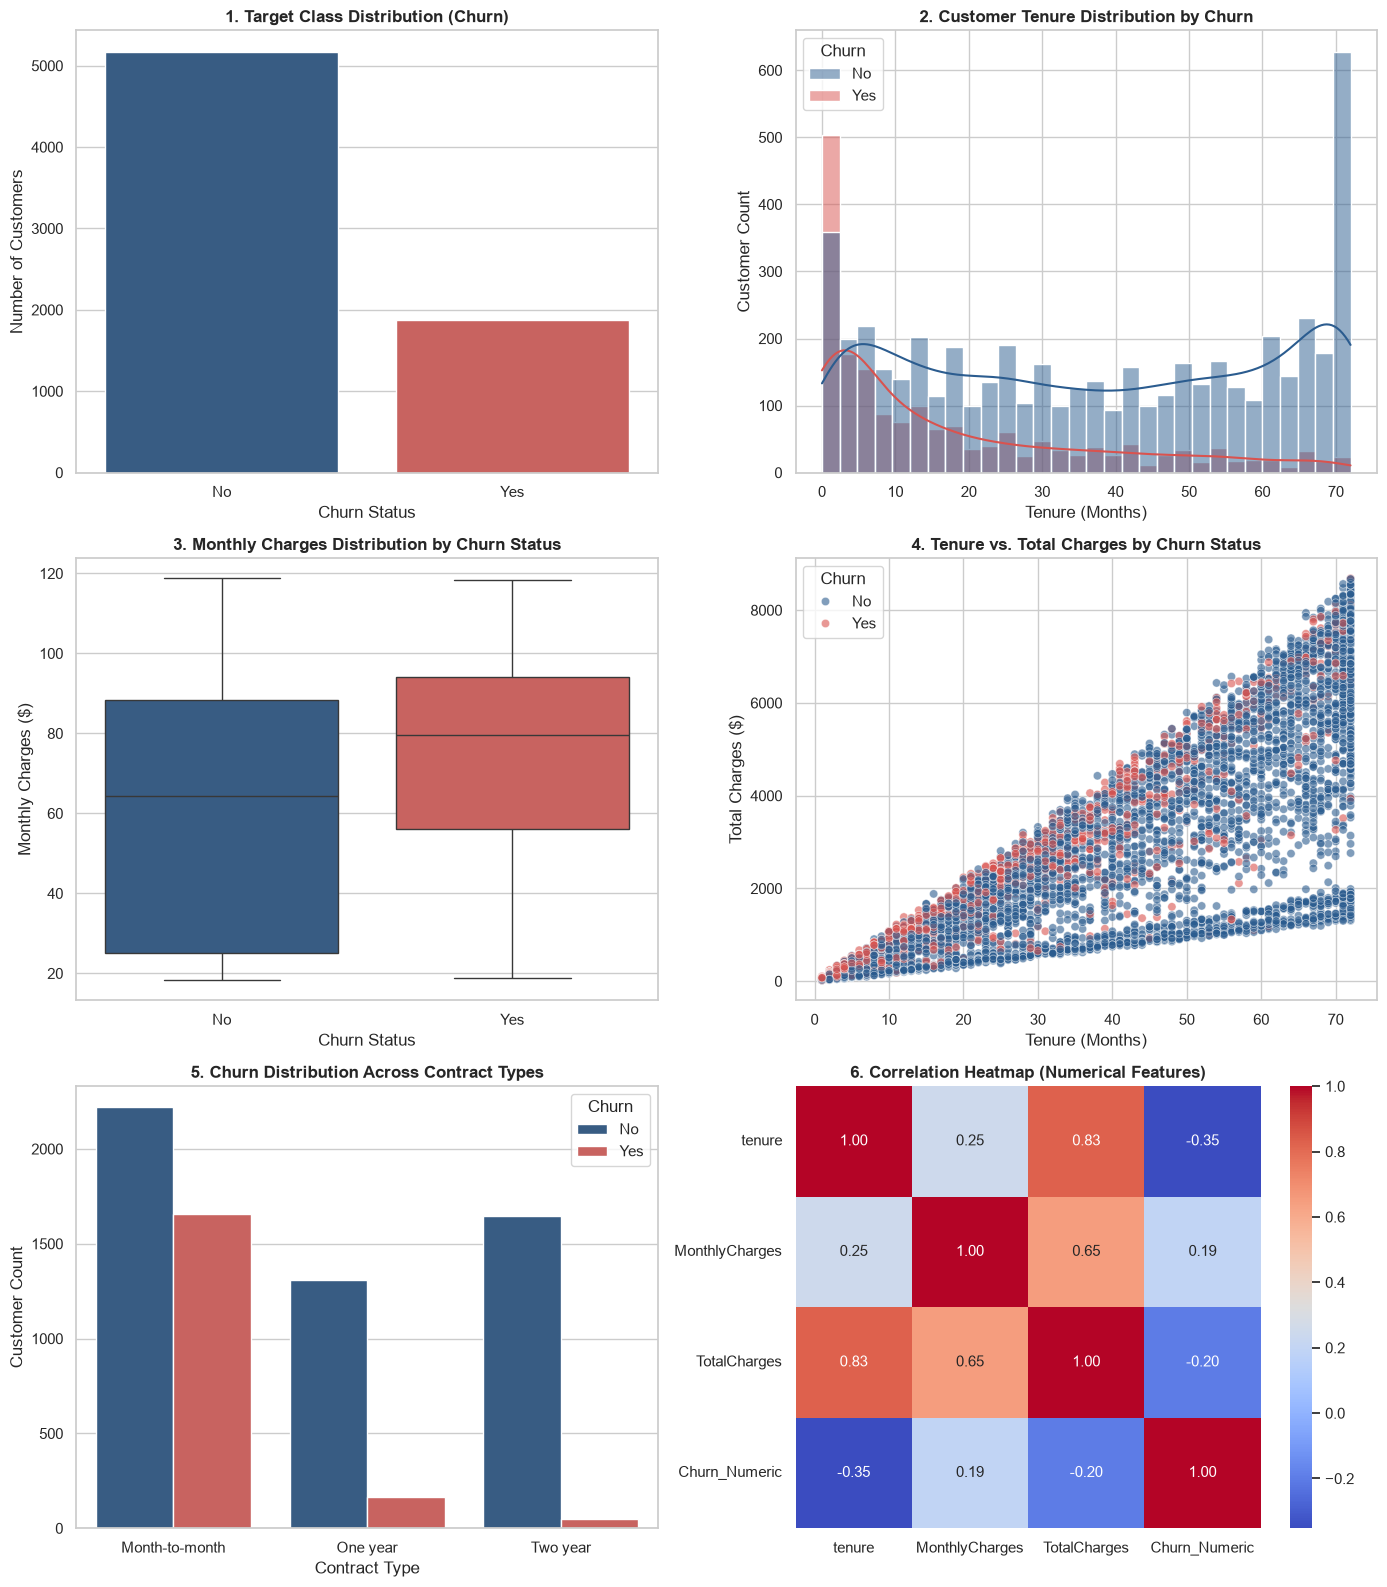

In [60]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Create a 3x2 plot canvas
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Plot 1: Count Plot - Target Distribution
sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[0, 0])
axes[0, 0].set_title('1. Target Class Distribution (Churn)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Churn Status')
axes[0, 0].set_ylabel('Number of Customers')


# Plot 2: Histogram - Tenure Distribution by Churn
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, palette=['#2b5c8f', '#d9534f'], ax=axes[0, 1])
axes[0, 1].set_title('2. Customer Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tenure (Months)')
axes[0, 1].set_ylabel('Customer Count')

# Plot 3: Box Plot - Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2b5c8f', '#d9534f'], ax=axes[1, 0])
axes[1, 0].set_title('3. Monthly Charges Distribution by Churn Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Churn Status')
axes[1, 0].set_ylabel('Monthly Charges ($)')


# Plot 4: Scatter Plot - Tenure vs Total Charges
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.6, palette=['#2b5c8f', '#d9534f'], ax=axes[1, 1])
axes[1, 1].set_title('4. Tenure vs. Total Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tenure (Months)')
axes[1, 1].set_ylabel('Total Charges ($)')


# Plot 5: Count Plot - Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[2, 0])
axes[2, 0].set_title('5. Churn Distribution Across Contract Types', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Contract Type')
axes[2, 0].set_ylabel('Customer Count')

# Plot 6: Correlation Heatmap
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn_Numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2, 1], cbar=True)
axes[2, 1].set_title('6. Correlation Heatmap (Numerical Features)', fontsize=12, fontweight='bold')

# Adjust layout and export figure for report insertion
plt.tight_layout()
plt.savefig('telco_churn_6_visualizations.png', dpi=300)
plt.show()